Jun0425: This file consists of 4 discontinuous 10-minute acquisitions that have been concatenated; one hour elapsed between the start of each acquisition. If you imagine this as a continuous 40-minute file for the sake of simplicity, stims. were applied at minutes 5, 15, 25, and 35; the corresponding time steps would be 122175, 366525, 610875, and 855225. As was true of the Jun0523 file, all of the applied stimuli here were identical except the one at 25 minutes, which was a perturbation stim. The breaks between the four constituent acquisitions occurred at 10, 20, and 30 minutes (244350, 488700, and 733050). One of the rationales for this experiment was to allow the population to (ostensibly) reestablish naivete between trials.

In [1]:
'''
import h5py

file_path = 'Jun0425_peaks.mat'

with h5py.File(file_path, 'r') as f:
    # List all variables in the MAT file
    print(list(f.keys()))

    # Example: access a variable called 'peaks'
    peaks = f['peaks'][:]
    print(peaks.shape)
'''

"\nimport h5py\n\nfile_path = 'Jun0425_peaks.mat'\n\nwith h5py.File(file_path, 'r') as f:\n    # List all variables in the MAT file\n    print(list(f.keys()))\n\n    # Example: access a variable called 'peaks'\n    peaks = f['peaks'][:]\n    print(peaks.shape)\n"

In [2]:
'''
## Save peaks as npy file
import numpy as np
np.save('Jun0425_peaks.npy', peaks)
'''

"\n## Save peaks as npy file\nimport numpy as np\nnp.save('Jun0425_peaks.npy', peaks)\n"

In [3]:
## Import peaks from npy file
import numpy as np
peaks = np.load('../data/sea_slug/Jun0425_peaks.npy')

In [4]:
peaks.shape

(976896, 72)

In [5]:
import sys
sys.getsizeof(peaks)

128

In [6]:
import numpy as np
def count_zeros_ones(series, n_bins):
    """
    Count the number of 0s and 1s in each bin of a 0/1 series.

    Parameters
    ----------
    series : array-like
        1D array or list of 0s and 1s.
    n_bins : int
        Number of bins to split the series into.

    Returns
    -------
    counts_0 : np.ndarray
        Array of counts of 0s per bin.
    counts_1 : np.ndarray
        Array of counts of 1s per bin.
    """
    ## Initial parameters
    series = np.asarray(series)
    bin_edges = np.linspace(0, len(series), n_bins + 1, dtype=int)
    counts_0 = np.zeros(n_bins, dtype=int)
    counts_1 = np.zeros(n_bins, dtype=int)
    ## Obtain the bins and counts per bin
    for i in range(n_bins):
        start = bin_edges[i]
        end = bin_edges[i + 1]
        bin_data = series[start:end]
        counts_0[i] = np.sum(bin_data == 0)
        counts_1[i] = np.sum(bin_data == 1)
    ## Return counts
    return counts_0, counts_1

In [7]:
n_bins = 40
n_nodes = peaks.shape[1]
counts_peaks = np.zeros((n_nodes, n_bins), dtype=int)
for i in range(n_nodes):
    counts_peaks[i] = count_zeros_ones(peaks[:,i], n_bins)[1]

In [8]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

In [9]:
n_gaps = 4
acquisition_duration = 10
acquisition_gap = 60

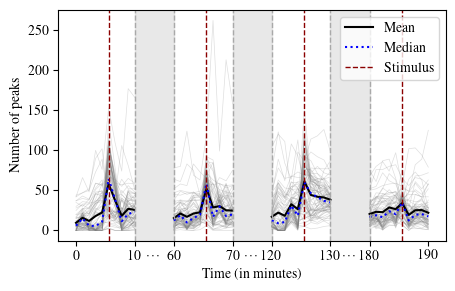

In [10]:
gaps = np.arange(n_gaps)
Q = n_bins // len(gaps)
offset = 5
range = np.max(counts_peaks) - np.min(counts_peaks)
xticks_pos = []
xticks_lab = []
plt.figure(figsize=(5, 3))
for gap in gaps:
    plt.plot(np.arange(Q) + (Q + offset) * gap, counts_peaks.T[(gap*Q):((gap+1)*Q)], color='gray', alpha=0.25, lw=0.5)
    if gap == 0:
        plt.plot(np.arange(Q) + (Q + offset) * gap, counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)], color='black', lw=1.5, label='Mean')
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(counts_peaks, axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=1.5, label='Median', ls='dotted')
    else:
        plt.plot(np.arange(Q) + (Q + offset) * gap, counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)], color='black', lw=1.5)
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(counts_peaks, axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=1.5, ls='dotted')
    if gap != 0:
        plt.axvline(x=gap * (Q + offset), color='darkgray', lw=1, ls='--')
    if gap != len(gaps) - 1:
        plt.axvline(x=(Q + offset) * gap + Q - 1, color='darkgray', lw=1, ls='--')
    xticks_pos += [gap * (Q + offset), (Q + offset) * gap + Q - 1]
    xticks_lab += [gap * acquisition_gap, gap * acquisition_gap + acquisition_duration] ## Probably add -1
    if gap != len(gaps) - 1:
        plt.text(((Q + offset) * gap + Q - 1 + (gap+1) * (Q + offset)) / 2, -range / 7, r'$\cdots$', ha='center', va='bottom')
        plt.axvspan((Q + offset) * gap + Q - 1, (gap+1) * (Q + offset), color='lightgray', alpha=0.5)
for j, p in enumerate([5, 15 + offset, 25 + 2 * offset, 35 + 3 * offset]):
    if j == 0:
        plt.axvline(x=p, ls='dashed', c='DarkRed', label='Stimulus', lw=1.0)
    else:
        plt.axvline(x=p, ls='dashed', c='DarkRed', lw=1.0)
plt.xticks(xticks_pos, xticks_lab)    
plt.xlabel('Time (in minutes)')
plt.ylabel('Number of peaks')
plt.legend()
plt.savefig('../figures/peaks_Jun0425.pdf', bbox_inches='tight')
plt.show()

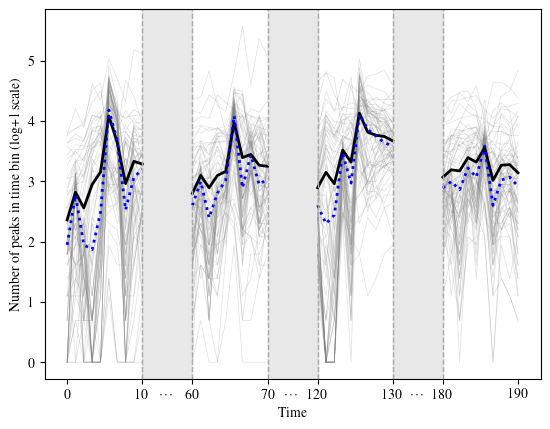

In [11]:
## Repeat on log+1 scale
log_range = np.max(np.log(counts_peaks + 1)) - np.min(np.log(counts_peaks + 1))
xticks_pos = []
xticks_lab = []
for gap in gaps:
    plt.plot(np.arange(Q) + (Q + offset) * gap, np.log(counts_peaks.T[(gap*Q):((gap+1)*Q)] + 1), color='gray', alpha=0.25, lw=0.5)
    if gap == 0:
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.log(counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)] + 1), color='black', lw=2, label='Mean')
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(np.log(counts_peaks + 1), axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=2, label='Median', ls='dotted')
    else:
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.log(counts_peaks.mean(axis=0)[(gap*Q):((gap+1)*Q)] + 1), color='black', lw=2)
        plt.plot(np.arange(Q) + (Q + offset) * gap, np.median(np.log(counts_peaks + 1), axis=0)[(gap*Q):((gap+1)*Q)], color='blue', lw=2, ls='dotted')
    if gap != 0:
        plt.axvline(x=gap * (Q + offset), color='darkgray', lw=1, ls='--')
    if gap != len(gaps) - 1:
        plt.axvline(x=(Q + offset) * gap + Q - 1, color='darkgray', lw=1, ls='--')
    xticks_pos += [gap * (Q + offset), (Q + offset) * gap + Q - 1]
    xticks_lab += [gap * acquisition_gap, gap * acquisition_gap + acquisition_duration] ## Probably add -1
    if gap != len(gaps) - 1:
        plt.text(((Q + offset) * gap + Q - 1 + (gap+1) * (Q + offset)) / 2, - log_range / 9, r'$\cdots$', ha='center', va='bottom')
        plt.axvspan((Q + offset) * gap + Q - 1, (gap+1) * (Q + offset), color='lightgray', alpha=0.5)
plt.xticks(xticks_pos, xticks_lab)    
plt.xlabel('Time')
plt.ylabel('Number of peaks in time bin (log+1 scale)')
plt.savefig('../figures/peaks_log_scale_Jun0425.pdf', bbox_inches='tight')
plt.show()